In [1]:
# Импорт библиотек
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sentence_transformers import SentenceTransformer, util
from transformers import GPT2Tokenizer, GPT2Model
import torch
from torch.utils.data import TensorDataset, DataLoader
from torch import nn
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt


C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:13: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


In [2]:
# Загрузка данных
df = pd.read_csv('email_text.csv', nrows=1000)

# Проверка на наличие null-значений и удаление их
df.dropna(inplace=True)

# Предобработка текста
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [3]:
df

,label,text
0,0,the mailing list i queried about a few weeks a...
1,1,luxury watches buy your own rolex for only esc...
2,1,academic qualifications available from prestig...
3,0,greetings all this is to verify your subscript...
4,1,try chauncey may conferred the luscious not co...
...,...,...
995,1,b b b wfescapenumber kescapenumbern i l kh es...
996,1,escapelong g escapenumber n c w r rescapenumb...
997,1,b d j escapenumber j n c k b escapenumber i e...
998,1,hi escapenumber a v p c l v x m a r i e i a b ...


In [4]:
def preprocess_text(text):
    text = text.lower()
    text = text.replace("n't", " not")
    text = text.replace("'m", " am")
    text = text.replace("'s", " is")
    text = text.replace("'re", " are")
    text = text.replace("'ve", " have")
    text = text.replace("'ll", " will")
    text = text.replace("'d", " would")
    text = text.replace("!", "")
    text = text.replace("?", "")
    text = text.replace(".", "")
    text = text.replace(",", "")
    text = text.replace(";", "")
    text = text.replace(":", "")
    text = text.replace("-", " ")
    text = text.replace("(", " ")
    text = text.replace(")", " ")
    text = " ".join([word for word in text.split() if word not in stop_words])
    text = " ".join([lemmatizer.lemmatize(word) for word in text.split()])
    text = text.strip()
    return text


In [5]:
df['text'] = df['text'].apply(preprocess_text)


In [6]:
# Загрузка предобученной модели
model_name = 'bert-base-uncased'
model = SentenceTransformer(model_name)

# Получение векторов
embeddings = model.encode(df['text'].tolist())

# Разделение на тестовую и обучающую выборки
train_size = int(0.8 * len(df))
X_train = embeddings[:train_size]
X_test = embeddings[train_size:]
y_train = df['label'][0:train_size]
y_test = df['label'][train_size:]

# Преобразование в тензоры PyTorch
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.long)
y_test = torch.tensor(y_test.values, dtype=torch.long)

# Создание DataLoader
train_data = TensorDataset(X_train, y_train)
test_data = TensorDataset(X_test, y_test)

batch_size = 32
train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

No sentence-transformers model found with name bert-base-uncased. Creating a new one with mean pooling.
C:\Users\User\AppData\Roaming\Python\Python310\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
C:\Users\User\AppData\Roaming\Python\Python310\site-packages\transformers\models\bert\modeling_bert.py:439: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


In [7]:
# Построение архитектуры нейронной сети
class SpamClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SpamClassifier, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.sigmoid(out)
        return out

Epoch 1/10, Train Loss: 0.4315, Train Accuracy: 0.9375, Test Loss: 0.4315, Test Accuracy: 0.7500
Epoch 2/10, Train Loss: 0.0925, Train Accuracy: 0.9688, Test Loss: 0.0925, Test Accuracy: 1.0000
Epoch 3/10, Train Loss: 0.1650, Train Accuracy: 0.9375, Test Loss: 0.1650, Test Accuracy: 0.8750
Epoch 4/10, Train Loss: 0.0929, Train Accuracy: 0.9062, Test Loss: 0.0929, Test Accuracy: 1.0000
Epoch 5/10, Train Loss: 0.0657, Train Accuracy: 1.0000, Test Loss: 0.0657, Test Accuracy: 1.0000
Epoch 6/10, Train Loss: 0.0866, Train Accuracy: 0.9688, Test Loss: 0.0866, Test Accuracy: 1.0000
Epoch 7/10, Train Loss: 0.0466, Train Accuracy: 0.9688, Test Loss: 0.0466, Test Accuracy: 1.0000
Epoch 8/10, Train Loss: 0.0943, Train Accuracy: 0.9688, Test Loss: 0.0943, Test Accuracy: 1.0000
Epoch 9/10, Train Loss: 0.0864, Train Accuracy: 1.0000, Test Loss: 0.0864, Test Accuracy: 1.0000
Epoch 10/10, Train Loss: 0.0128, Train Accuracy: 0.9688, Test Loss: 0.0128, Test Accuracy: 1.0000
Accuracy: 0.9400
F1-score: 0.

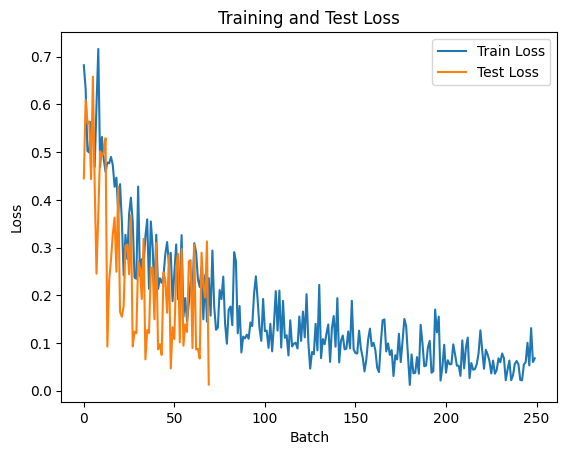

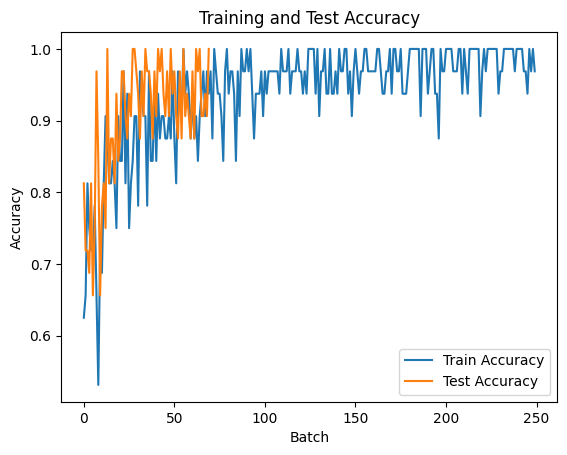

In [8]:
# Обучение модели
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SpamClassifier(X_train.shape[1], 128, 1).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 10
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(epochs):
    model.train()
    for batch in train_dataloader:
        inputs, labels = batch
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs.squeeze(), labels.float())
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        train_accuracies.append(accuracy_score(labels.cpu(), (outputs.squeeze() > 0.5).cpu()))

    model.eval()
    with torch.no_grad():
        for batch in test_dataloader:
            inputs, labels = batch
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs.squeeze(), labels.float())

            test_losses.append(loss.item())
            test_accuracies.append(accuracy_score(labels.cpu(), (outputs.squeeze() > 0.5).cpu()))

    print(f'Epoch {epoch + 1}/{epochs}, Train Loss: {loss.item():.4f}, Train Accuracy: {train_accuracies[-1]:.4f}, Test Loss: {loss.item():.4f}, Test Accuracy: {test_accuracies[-1]:.4f}')

# Оценка работы модели
model.eval()
with torch.no_grad():
    y_pred = model(X_test.to(device))
    y_pred = (y_pred.squeeze() > 0.5).cpu()

accuracy = accuracy_score(y_test.cpu(), y_pred)
f1 = f1_score(y_test.cpu(), y_pred)

print(f'Accuracy: {accuracy:.4f}')
print(f'F1-score: {f1:.4f}')
# Построение графиков
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title('Training and Test Loss')
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.title('Training and Test Accuracy')
plt.xlabel('Batch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()



## GPT-2

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [10]:
# Загрузка предобученной модели GPT-2
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token
model = GPT2Model.from_pretrained('gpt2')

C:\Users\User\AppData\Roaming\Python\Python310\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [11]:
model.to(device)

GPT2Model(
  (wte): Embedding(50257, 768)
  (wpe): Embedding(1024, 768)
  (drop): Dropout(p=0.1, inplace=False)
  (h): ModuleList(
    (0-11): 12 x GPT2Block(
      (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (attn): GPT2SdpaAttention(
        (c_attn): Conv1D()
        (c_proj): Conv1D()
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (mlp): GPT2MLP(
        (c_fc): Conv1D()
        (c_proj): Conv1D()
        (act): NewGELUActivation()
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
)

In [12]:
# Tokenize и pad sequences
encoded_captions = tokenizer(
    df['text'].tolist(),
    return_tensors='pt',
    padding=True,
    truncation=True)

In [13]:
encoded_captions = {key: value.to(device) for key, value in encoded_captions.items()}
input_ids = encoded_captions['input_ids']

In [14]:
batch_size = 4

In [15]:
# Задаем padding token
tokenizer.pad_token = tokenizer.eos_token
tokenizer.model_max_length = 512
torch.cuda.empty_cache()

# Перезагружаем токенизатор
tokenizer = GPT2Tokenizer.from_pretrained('gpt2', pad_token=tokenizer.pad_token) 

def get_gpt2_embeddings(texts):
    encoded_input = tokenizer(texts, padding=True, truncation=True, return_tensors='pt').to(device)
    outputs = model(**encoded_input) 
    embeddings = outputs.last_hidden_state[:, 0, :]
    return embeddings


In [16]:
# Инициализируем список для хранения embeddings
all_sentence_embeddings = []

# Разделим данные на батчи и передадим их в модель
for i in range(0, len(encoded_captions['input_ids']), batch_size):
    batch_input_ids = encoded_captions['input_ids'][i:i+batch_size].to(device)
    batch_attention_mask = encoded_captions['attention_mask'][i:i+batch_size].to(device)

    # Передаем батчи в модель
    with torch.no_grad():
        batch_outputs = model(batch_input_ids)

    # Извлекаем embeddings для каждого батча
    word_embeddings = batch_outputs.last_hidden_state

    # Mask для игнорирования padding tokens
    masked_word_embeddings = word_embeddings * batch_attention_mask.unsqueeze(-1).float()

    # Объединение сумм с учётом токенов без non-padding
    sentence_embeddings = masked_word_embeddings.sum(dim=1)

    # Нормализация по количеству токенов без non-padding
    sentence_embeddings /= batch_attention_mask.sum(dim=1, keepdim=True).float()

    # Добавляем embeddings батча в список
    all_sentence_embeddings.append(sentence_embeddings)

# Собираем все embeddings батчей в один список
all_sentence_embeddings = torch.cat(all_sentence_embeddings, dim=0)

In [18]:
from sklearn.model_selection import train_test_split
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(all_sentence_embeddings, y, test_size=0.2, random_state=42)

In [19]:
# Преобразование данных в тензоры PyTorch
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

# Создание DataLoader для обучающего и тестового наборов данных
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32)

C:\Users\User\AppData\Local\Temp\ipykernel_11056\1625074107.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
C:\Users\User\AppData\Local\Temp\ipykernel_11056\1625074107.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test_tensor = torch.tensor(X_test, dtype=torch.float32)


In [21]:
# Обучение модели

model = SpamClassifier(X_train.shape[1], 128, 1).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 10
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(epochs):
    model.train()
    for batch in train_dataloader:
        inputs, labels = batch
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs.squeeze(), labels.float())
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        train_accuracies.append(accuracy_score(labels.cpu(), (outputs.squeeze() > 0.5).cpu()))

    model.eval()
    with torch.no_grad():
        for batch in test_dataloader:
            inputs, labels = batch
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs.squeeze(), labels.float())

            test_losses.append(loss.item())
            test_accuracies.append(accuracy_score(labels.cpu(), (outputs.squeeze() > 0.5).cpu()))
    print(f'Epoch {epoch + 1}/{epochs}, Train Loss: {loss.item():.4f}, Train Accuracy: {train_accuracies[-1]:.4f}, Test Loss: {loss.item():.4f}, Test Accuracy: {test_accuracies[-1]:.4f}')

#  y_test в тензор PyTorch
y_test = torch.tensor(y_test.values, dtype=torch.long)

# Оценка работы модели
model.eval()
with torch.no_grad():
    y_pred = model(X_test.to(device))
    y_pred = (y_pred.squeeze() > 0.5).cpu()

# Переместите y_test на CPU
accuracy = accuracy_score(y_test.to('cpu'), y_pred)
f1 = f1_score(y_test.to('cpu'), y_pred)

print(f'Accuracy: {accuracy:.4f}')
print(f'F1-score: {f1:.4f}')

Epoch 1/10, Train Loss: 0.3019, Train Accuracy: 0.8125, Test Loss: 0.3019, Test Accuracy: 1.0000
Epoch 2/10, Train Loss: 0.1886, Train Accuracy: 0.8750, Test Loss: 0.1886, Test Accuracy: 1.0000
Epoch 3/10, Train Loss: 0.1611, Train Accuracy: 0.8750, Test Loss: 0.1611, Test Accuracy: 1.0000
Epoch 4/10, Train Loss: 0.0953, Train Accuracy: 0.8750, Test Loss: 0.0953, Test Accuracy: 1.0000
Epoch 5/10, Train Loss: 0.0830, Train Accuracy: 0.9375, Test Loss: 0.0830, Test Accuracy: 1.0000
Epoch 6/10, Train Loss: 0.0542, Train Accuracy: 1.0000, Test Loss: 0.0542, Test Accuracy: 1.0000
Epoch 7/10, Train Loss: 0.0349, Train Accuracy: 1.0000, Test Loss: 0.0349, Test Accuracy: 1.0000
Epoch 8/10, Train Loss: 0.0263, Train Accuracy: 0.9688, Test Loss: 0.0263, Test Accuracy: 1.0000
Epoch 9/10, Train Loss: 0.0292, Train Accuracy: 1.0000, Test Loss: 0.0292, Test Accuracy: 1.0000
Epoch 10/10, Train Loss: 0.0275, Train Accuracy: 1.0000, Test Loss: 0.0275, Test Accuracy: 1.0000
Accuracy: 0.9800
F1-score: 0.